<a href="https://colab.research.google.com/github/azelepou/colab-test/blob/main/ML_HW_AnatolyZelepouga_801236217_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rows: 100; input columns: X1, X2, X3; target: Y
Column minima: [ 0.          0.07030303  0.02787879 -5.33245499]
Column maxima: [4.         3.94909091 3.9430303  5.54589212]
Initial cost with zero parameters: 5.524438459
Model  Alpha  Iterations       Final J          MSE
X1     0.01        8453   0.984993083   1.969986165
X1     0.03        2977   0.984993083   1.969986165
X1     0.05        1829   0.984993083   1.969986165
X1     0.10         941   0.984993083   1.969986165
X2     0.01        7299   3.599366018   7.198732036
X2     0.03        2593   3.599366018   7.198732036
X2     0.05        1599   3.599366018   7.198732036
X2     0.10         827   3.599366018   7.198732036
X3     0.01        7989   3.629451125   7.258902249
X3     0.03        2820   3.629451125   7.258902249
X3     0.05        1734   3.629451125   7.258902249
X3     0.10         893   3.629451125   7.258902249
All    0.01       17844   0.738464242   1.476928483
All    0.03        6310   0.738464242   1.476928483

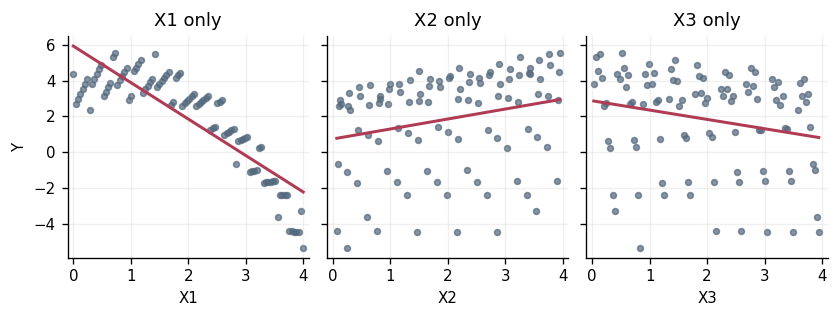

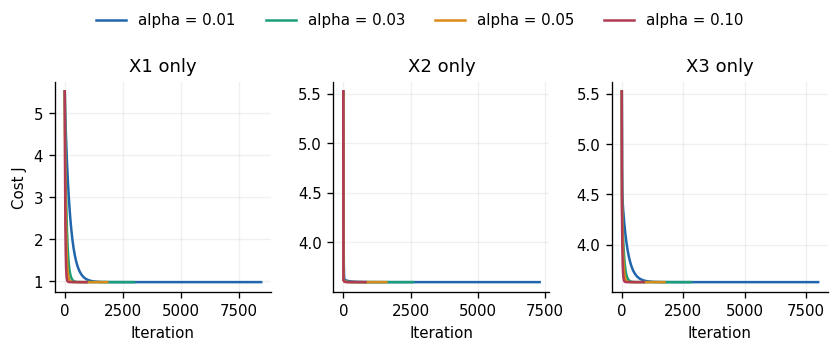

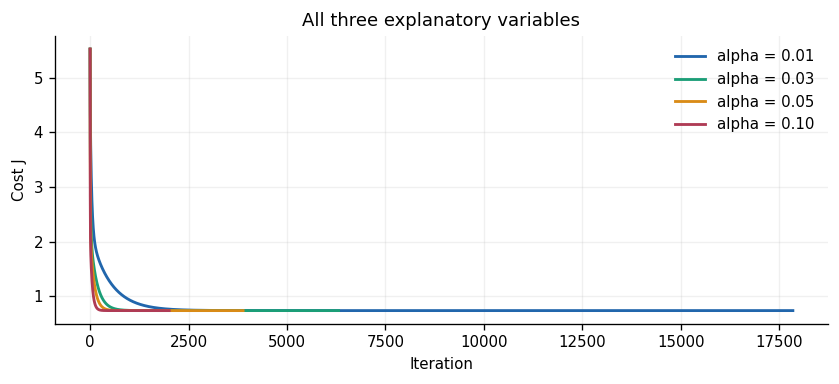

 X1  X2  X3   Predicted Y
  1   1   1   3.577409369
  2   0   4   0.244321172
  3   2   1   0.102534172
Cost reduction versus the best single input: 25.03%


In [4]:
# %% 1 Load the data and set up the experiment

from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

DATA = Path("D3.csv")
OUT = Path("results")
OUT.mkdir(exist_ok=True)

data = np.loadtxt(DATA, delimiter=",", skiprows=1)

if data.ndim != 2 or data.shape[1] != 4:
    raise ValueError("D3.csv must have four numeric columns.")

if not np.isfinite(data).all():
    raise ValueError("The data contains missing or nonfinite values.")

features, y = data[:, :3], data[:, 3]
m = len(y)

alphas = [0.01, 0.03, 0.05, 0.10]
# Learning rates

step_tolerance = 1e-10
max_iterations = 100000

colors = ["#2166AC", "#1B9E77", "#D98B17", "#AF3B55"]

plt.rcParams.update({
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120
})

print(f"Rows: {m}; input columns: X1, X2, X3; target: Y")
print("Column minima:", data.min(axis=0))
print("Column maxima:", data.max(axis=0))
print(f"Initial cost with zero parameters: {np.mean(y**2) / 2:.9f}")


# %% 2 Implement batch gradient descent from scratch

def gradient_descent(X, y, alpha,
                     step_tol=1e-10,
                     max_iter=100000):
    """Minimize J = sum((X @ theta - y)**2) / (2*m)."""

    m = len(y)

    theta = np.zeros(X.shape[1])

    error = X @ theta - y

    history = [
        float(error @ error / (2 * m))
    ]

    iteration = 0

    while iteration < max_iter:

        gradient = X.T @ error / m

        new_theta = theta - alpha * gradient

        step_size = np.sqrt(
            np.sum((new_theta - theta) ** 2)
        )

        theta = new_theta

        error = X @ theta - y

        cost = float(error @ error / (2 * m))

        if not np.isfinite(cost) or not np.isfinite(step_size):
            # Stop if the cost or parameter update is not finite
            raise FloatingPointError("Training diverged.")

        history.append(cost)

        iteration += 1

        # Stop when the parameter change is sufficiently small
        if step_size <= step_tol:
            break

    else:
        raise RuntimeError("The iteration limit was reached.")

    return theta, np.asarray(history), iteration


#3 Train the separate and combined models

designs = {
    "X1": np.column_stack((
        np.ones(m),
        features[:, 0]
    )),

    "X2": np.column_stack((
        np.ones(m),
        features[:, 1]
    )),

    "X3": np.column_stack((
        np.ones(m),
        features[:, 2]
    )),

    "All": np.column_stack((
        np.ones(m),
        features
    ))
}

runs = {}
records = []

for name, X in designs.items():
    # Train each model using each selected learning rate

    runs[name] = {}

    for alpha in alphas:

        theta, loss, steps = gradient_descent(
            X,
            y,
            alpha,
            step_tolerance,
            max_iterations
        )

        runs[name][alpha] = (
            theta,
            loss,
            steps
        )

        records.append([
            name,
            alpha,
            steps,
            loss[-1],
            2 * loss[-1]
        ])

print("Model  Alpha  Iterations       Final J          MSE")

for name, alpha, steps, cost, mse in records:
    print(
        f"{name:5}  "
        f"{alpha:.2f}  "
        f"{steps:10d}  "
        f"{cost:12.9f}  "
        f"{mse:12.9f}"
    )

with (OUT / "learning_rate_results.csv").open(
    "w",
    newline=""
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "model",
        "alpha",
        "iterations",
        "cost_J",
        "MSE"
    ])

    writer.writerows(records)

chosen_alpha = 0.10
# Fastest tested rate; final costs are effectively tied

for name in designs:
    print(
        f"{name} parameters at alpha=0.10:",
        runs[name][chosen_alpha][0]
    )


# Plot the final single-variable regression models

fig, axes = plt.subplots(
    1,
    3,
    figsize=(7.0, 2.65),
    sharey=True
)

for j, (name, ax) in enumerate(
    zip(["X1", "X2", "X3"], axes)
):

    x = features[:, j]

    theta = runs[name][chosen_alpha][0]

    x_line = np.linspace(
        x.min(),
        x.max(),
        150
    )

    ax.scatter(
        x,
        y,
        s=12,
        color="#54687D",
        alpha=0.70
    )

    ax.plot(
        x_line,
        theta[0] + theta[1] * x_line,
        color="#AF3B55",
        linewidth=1.8
    )

    ax.set(
        title=f"{name} only",
        xlabel=name,
        xlim=(-0.1, 4.1)
    )

    ax.grid(alpha=0.18)

axes[0].set_ylabel("Y")

fig.tight_layout(pad=0.8)

fig.savefig(
    OUT / "single_variable_fits.png",
    dpi=240
)

plt.show()



fig, axes = plt.subplots(
    1,
    3,
    figsize=(7.0, 2.9)
)

for name, ax in zip(
    ["X1", "X2", "X3"],
    axes
):

    for alpha, color in zip(alphas, colors):

        loss = runs[name][alpha][1]

        ax.plot(
            np.arange(len(loss)),
            loss,
            color=color,
            label=f"alpha = {alpha:.2f}",
            linewidth=1.5
        )

    ax.set(
        title=f"{name} only",
        xlabel="Iteration"
    )

    ax.grid(alpha=0.18)

axes[0].set_ylabel("Cost J")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    frameon=False
)

fig.tight_layout(
    rect=(0, 0, 1, 0.88),
    pad=0.8
)

fig.savefig(
    OUT / "single_variable_losses.png",
    dpi=240
)

plt.show()


#Plot the loss for the combined model

fig, ax = plt.subplots(
    figsize=(7.0, 3.2)
)

for alpha, color in zip(alphas, colors):

    loss = runs["All"][alpha][1]

    ax.plot(
        np.arange(len(loss)),
        loss,
        color=color,
        label=f"alpha = {alpha:.2f}",
        linewidth=1.7
    )

ax.set(
    xlabel="Iteration",
    ylabel="Cost J",
    title="All three explanatory variables"
)

ax.legend(frameon=False)
ax.grid(alpha=0.18)

fig.tight_layout(pad=0.8)

fig.savefig(
    OUT / "multiple_variable_losses.png",
    dpi=240
)

plt.show()


#Predict the three requested outputs

new_points = np.array([
    [1, 1, 1],
    [2, 0, 4],
    [3, 2, 1]
], dtype=float)

theta = runs["All"][chosen_alpha][0]

new_design = np.column_stack((
    np.ones(len(new_points)),
    new_points
))

predictions = new_design @ theta

print(" X1  X2  X3   Predicted Y")

for point, value in zip(
    new_points,
    predictions
):

    print(
        f"{point[0]:3.0f} "
        f"{point[1]:3.0f} "
        f"{point[2]:3.0f} "
        f"{value:13.9f}"
    )

with (OUT / "predictions.csv").open(
    "w",
    newline=""
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "X1",
        "X2",
        "X3",
        "predicted_Y"
    ])

    writer.writerows(
        np.column_stack((
            new_points,
            predictions
        ))
    )

best_single = min(
    runs[name][chosen_alpha][1][-1]
    for name in ["X1", "X2", "X3"]
)

combined_cost = runs["All"][chosen_alpha][1][-1]

improvement = (
    100
    * (best_single - combined_cost)
    / best_single
)

print(
    f"Cost reduction versus the best single input: "
    f"{improvement:.2f}%"
)